In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style("darkgrid")
print("✅ Imports OK | TF:", tf.__version__)

# Détection du chemin dataset
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Chargement
# Correction du chemin
BASE_PATH = "/kaggle/input/datasets/shayanfazeli/heartbeat"

train_df = pd.read_csv(f"{BASE_PATH}/mitbih_train.csv", header=None)
test_df  = pd.read_csv(f"{BASE_PATH}/mitbih_test.csv",  header=None)

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:,  -1].values.astype(int)
X_test  = test_df.iloc[:, :-1].values
y_test  = test_df.iloc[:,  -1].values.astype(int)

class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']

print("\n📐 Dimensions :")
print(f"   X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"   X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

print("\n📊 Distribution des classes (Train) :")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"   Classe {cls} ({class_names[cls]}) : {cnt} ({cnt/len(y_train)*100:.2f}%)")

display(train_df.head())


2026-04-29 16:33:17.746882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777480397.986913      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777480398.055768      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777480398.642961      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777480398.643012      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777480398.643015      23 computation_placer.cc:177] computation placer alr

✅ Imports OK | TF: 2.19.0
/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_abnormal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_normal.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv
/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv

📐 Dimensions :
   X_train : (87554, 187)  |  y_train : (87554,)
   X_test  : (21892, 187)   |  y_test  : (21892,)

📊 Distribution des classes (Train) :
   Classe 0 (Normal) : 72471 (82.77%)
   Classe 1 (Supraventricular) : 2223 (2.54%)
   Classe 2 (Ventricular) : 5788 (6.61%)
   Classe 3 (Fusion) : 641 (0.73%)
   Classe 4 (Unknown) : 6431 (7.35%)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


      ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

📋 Statistiques descriptives (Train) :
             mean         std    min    max
count  187.000000  187.000000  187.0  187.0
mean     0.174283    0.175429    0.0    1.0
std      0.130864    0.058597    0.0    0.0
min      0.002807    0.031924    0.0    1.0
25%      0.047416    0.149939    0.0    1.0
50%      0.201814    0.192567    0.0    1.0
75%      0.271643    0.220874    0.0    1.0
max      0.890360    0.251927    0.0    1.0

   Valeur min globale  : 0.0000
   Valeur max globale  : 1.0000
   Moyenne globale     : 0.1743
   Écart-type global   : 0.2263
   Valeurs manquantes  : 0


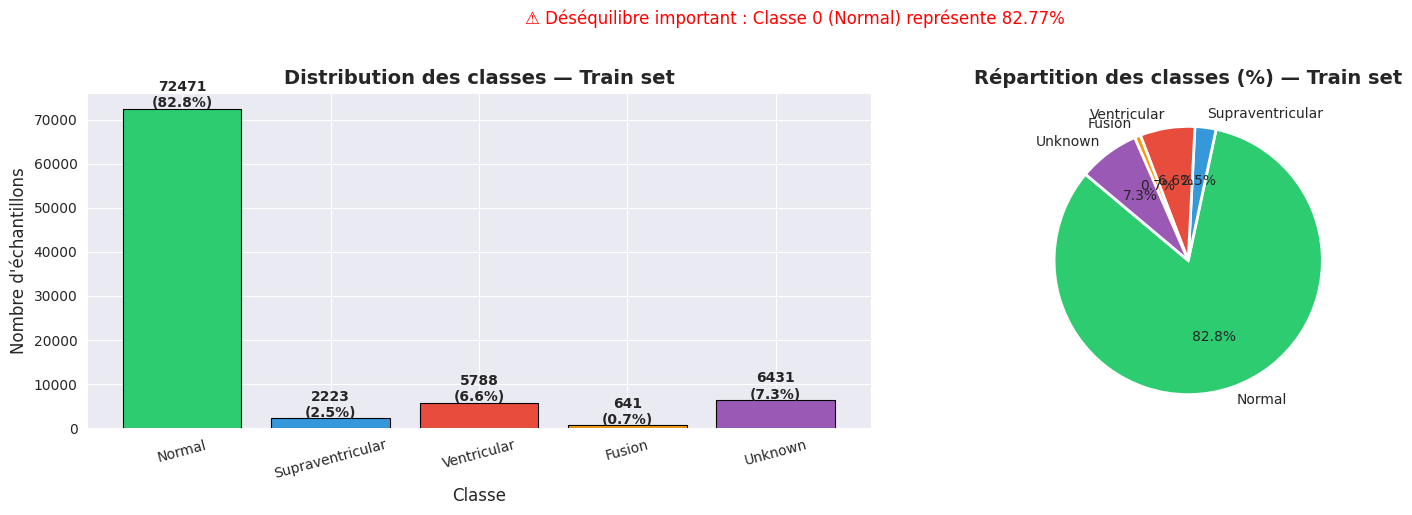

✅ Figure 1 sauvegardée : class_distribution.png


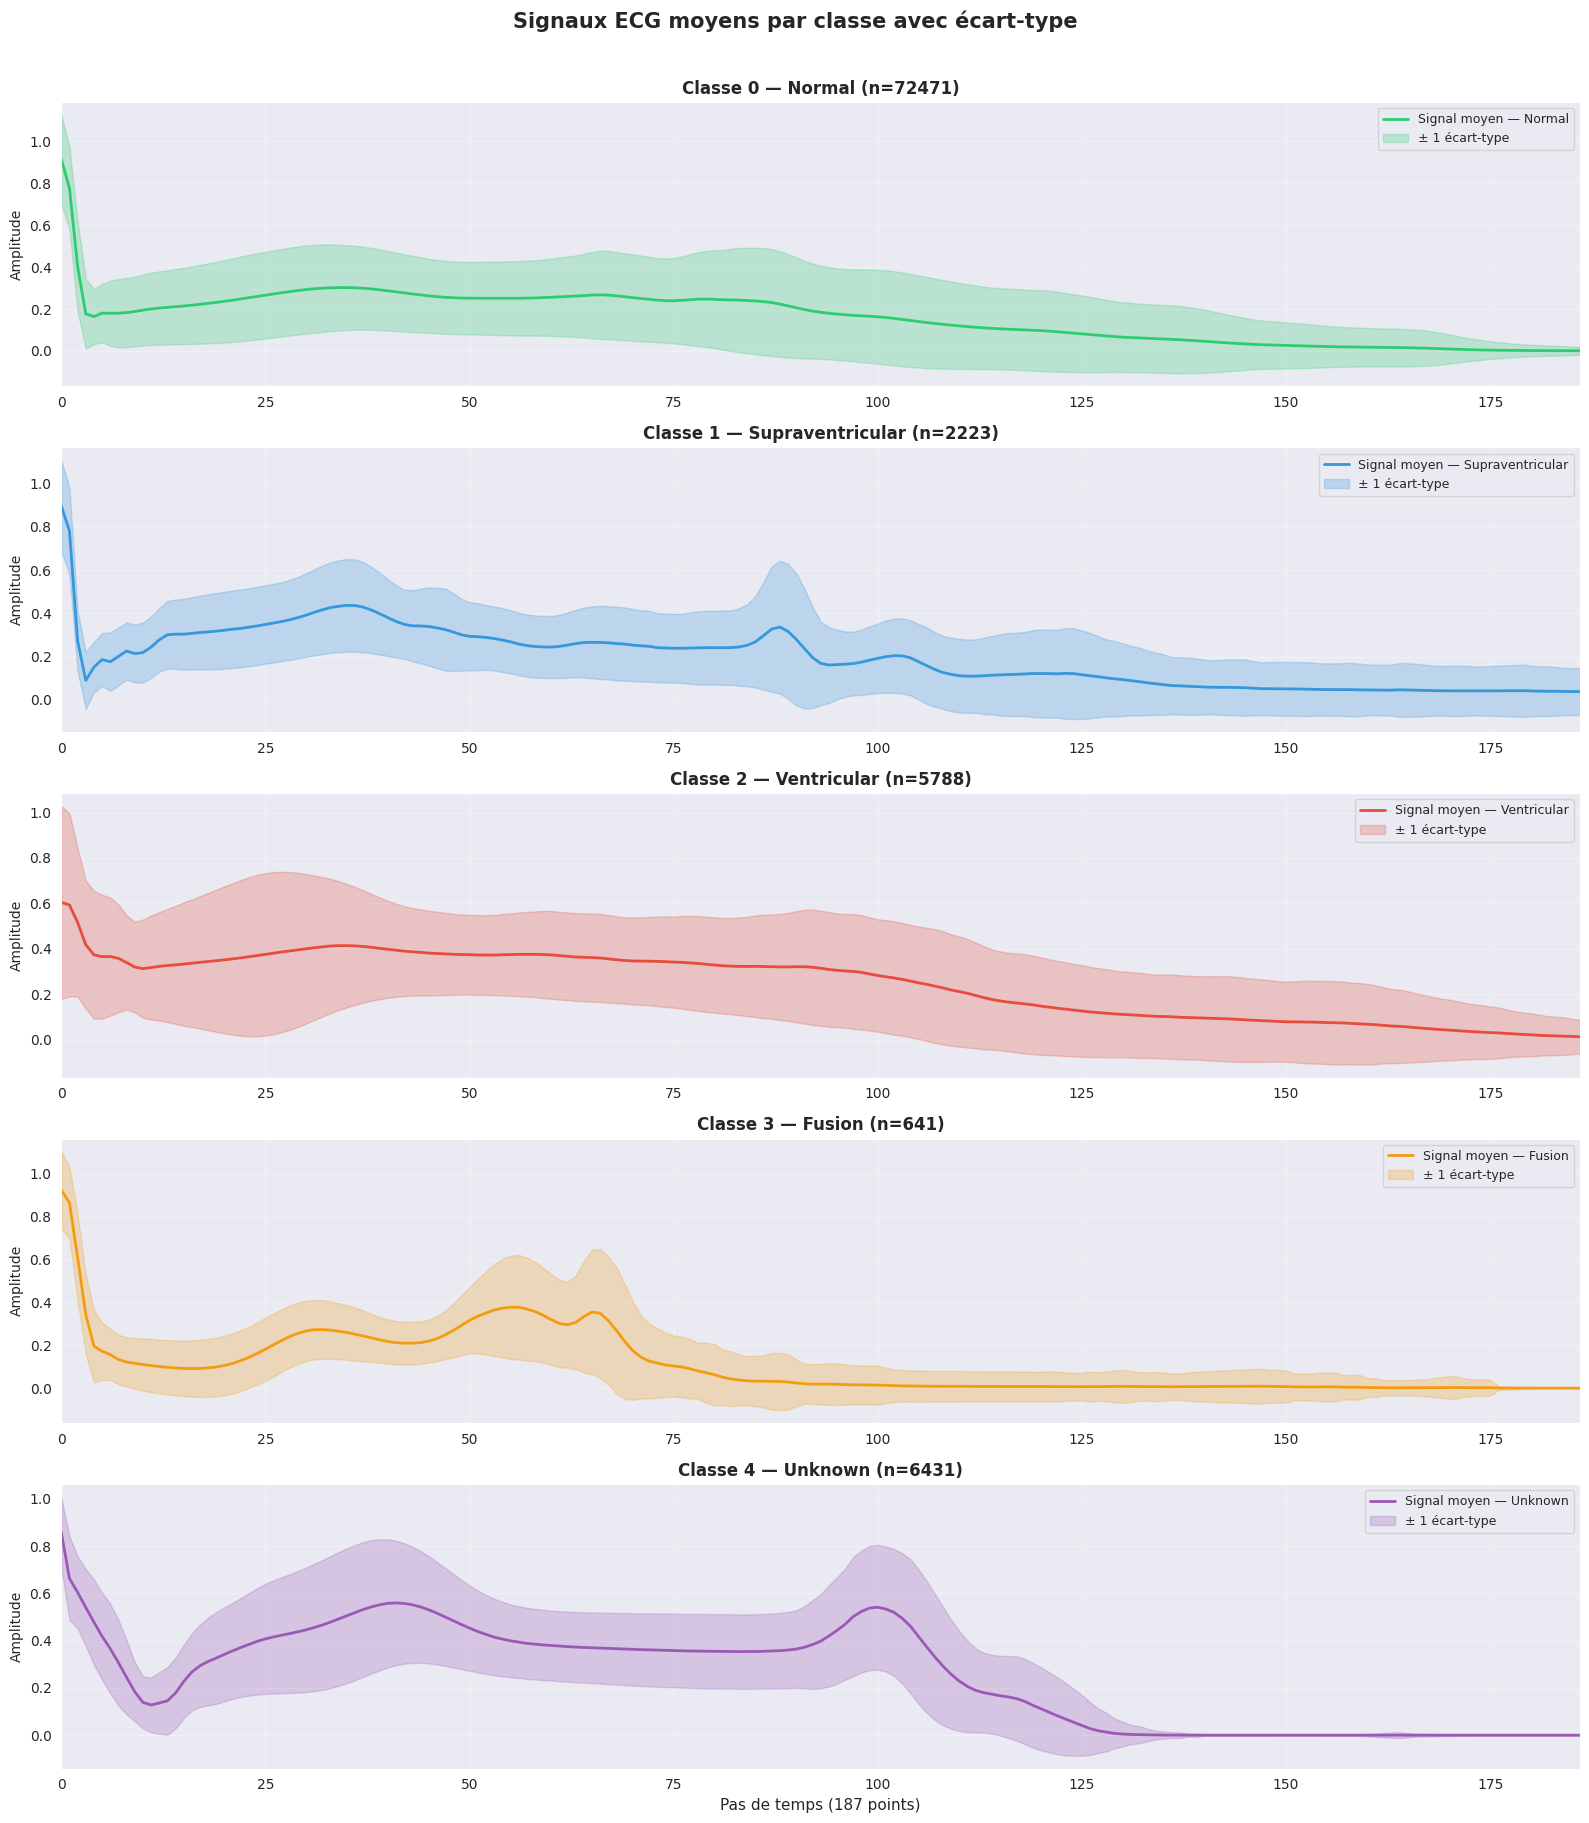

✅ Figure 2 sauvegardée : mean_ecg_signals.png


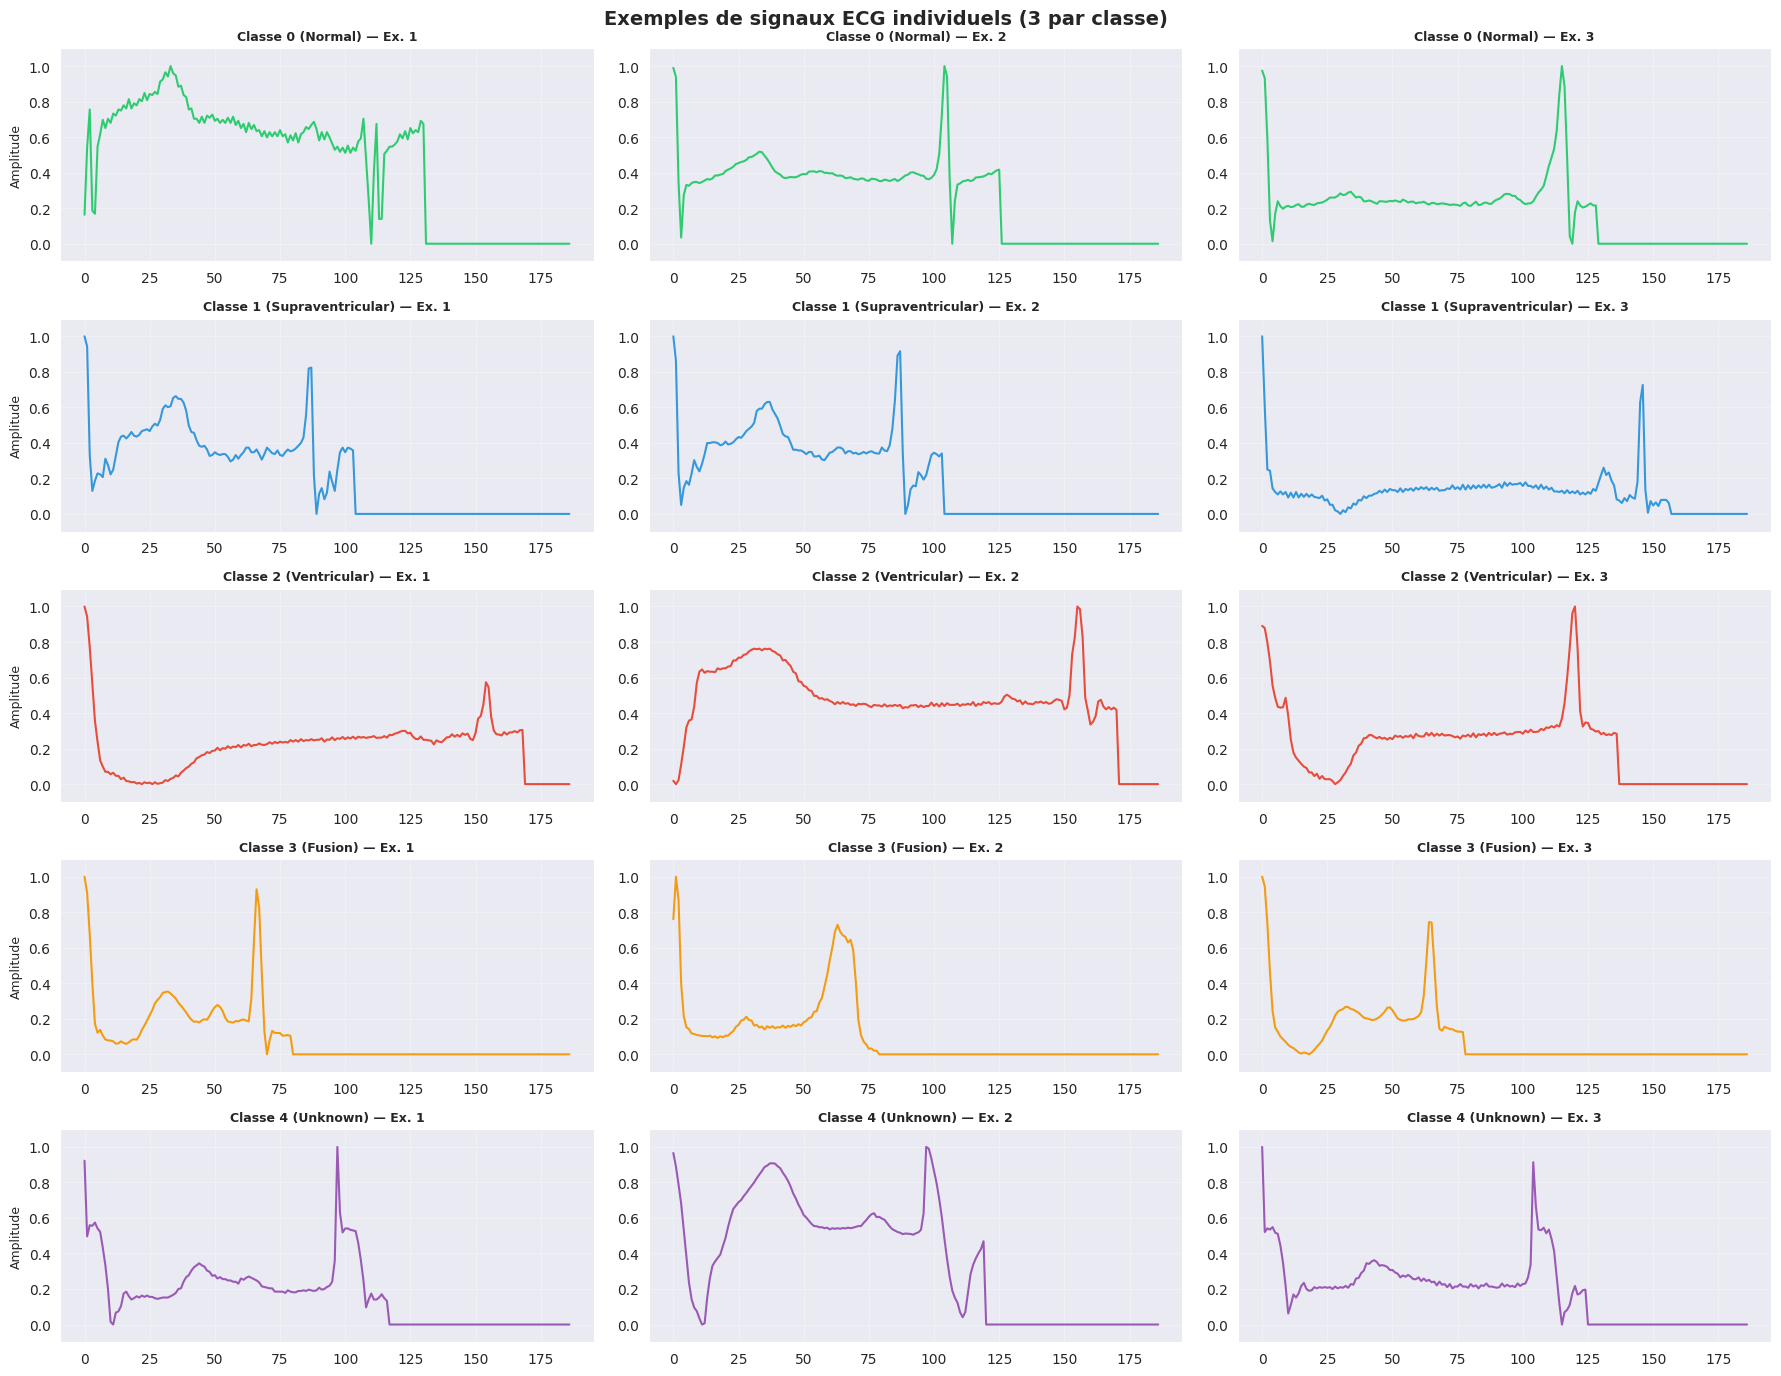

✅ Figure 3 sauvegardée : ecg_samples.png

✅ EDA terminée ! 3 figures générées.


In [2]:
# ============================================================
# CELLULE 2 — Analyse Exploratoire des Données (EDA)
# ============================================================

print("=" * 60)
print("      ANALYSE EXPLORATOIRE DES DONNÉES (EDA)")
print("=" * 60)

# ------------------------------------------------------------
# 2.1 Statistiques descriptives
# ------------------------------------------------------------
print("\n📋 Statistiques descriptives (Train) :")
stats_df = pd.DataFrame(X_train).describe().T
print(stats_df[['mean', 'std', 'min', 'max']].describe())

print(f"\n   Valeur min globale  : {X_train.min():.4f}")
print(f"   Valeur max globale  : {X_train.max():.4f}")
print(f"   Moyenne globale     : {X_train.mean():.4f}")
print(f"   Écart-type global   : {X_train.std():.4f}")
print(f"   Valeurs manquantes  : {np.isnan(X_train).sum()}")

# ------------------------------------------------------------
# 2.2 Distribution des classes — Barplot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

unique, counts = np.unique(y_train, return_counts=True)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

axes[0].bar([class_names[i] for i in unique], counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title("Distribution des classes — Train set", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Classe", fontsize=12)
axes[0].set_ylabel("Nombre d'échantillons", fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
for i, (cls, cnt) in enumerate(zip(unique, counts)):
    axes[0].text(i, cnt + 300, f'{cnt}\n({cnt/len(y_train)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=[class_names[i] for i in unique],
            autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Répartition des classes (%) — Train set", fontsize=14, fontweight='bold')

plt.suptitle("⚠️ Déséquilibre important : Classe 0 (Normal) représente 82.77%",
             fontsize=12, color='red', y=1.02)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 sauvegardée : class_distribution.png")

# ------------------------------------------------------------
# 2.3 Signal ECG moyen par classe
# ------------------------------------------------------------
fig, axes = plt.subplots(5, 1, figsize=(16, 18))
time_axis = np.arange(X_train.shape[1])

for cls_idx in range(5):
    mask = (y_train == cls_idx)
    signals_cls = X_train[mask]
    mean_signal = signals_cls.mean(axis=0)
    std_signal  = signals_cls.std(axis=0)

    ax = axes[cls_idx]
    ax.plot(time_axis, mean_signal, color=colors[cls_idx],
            linewidth=2, label=f'Signal moyen — {class_names[cls_idx]}')
    ax.fill_between(time_axis,
                    mean_signal - std_signal,
                    mean_signal + std_signal,
                    alpha=0.25, color=colors[cls_idx],
                    label='± 1 écart-type')
    ax.set_title(f"Classe {cls_idx} — {class_names[cls_idx]} (n={mask.sum()})",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("Amplitude", fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, X_train.shape[1] - 1)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Pas de temps (187 points)", fontsize=11)
plt.suptitle("Signaux ECG moyens par classe avec écart-type",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("mean_ecg_signals.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 2 sauvegardée : mean_ecg_signals.png")

# ------------------------------------------------------------
# 2.4 Exemples de signaux individuels par classe
# ------------------------------------------------------------
fig, axes = plt.subplots(5, 3, figsize=(18, 14))
np.random.seed(42) # Garantit la reproductibilité des échantillons
for cls_idx in range(5):
    mask = np.where(y_train == cls_idx)[0]
    samples = np.random.choice(mask, size=3, replace=False)
    for j, sample_idx in enumerate(samples):
        ax = axes[cls_idx][j]
        ax.plot(X_train[sample_idx], color=colors[cls_idx], linewidth=1.5)
        ax.set_title(f"Classe {cls_idx} ({class_names[cls_idx]}) — Ex. {j+1}",
                     fontsize=9, fontweight='bold')
        ax.set_ylim(-0.1, 1.1)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.set_ylabel("Amplitude", fontsize=9)

plt.suptitle("Exemples de signaux ECG individuels (3 par classe)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("ecg_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 sauvegardée : ecg_samples.png")

print("\n✅ EDA terminée ! 3 figures générées.")


         PRÉTRAITEMENT DES DONNÉES

🔍 3.1 — Vérification des données...
   Valeurs manquantes (train) : 0
   Valeurs infinies  (train)  : 0
   Valeurs < 0               : 0
   Valeurs > 1               : 0
   ✅ Données déjà propres et normalisées [0, 1]

🏷️  3.2 — Encodage des labels...
   y_train entier  : (87554,)   — ex: [0 0 0]
   y_train one-hot : (87554, 5) — ex:
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]

📏 3.3 — Comparaison des stratégies de normalisation...


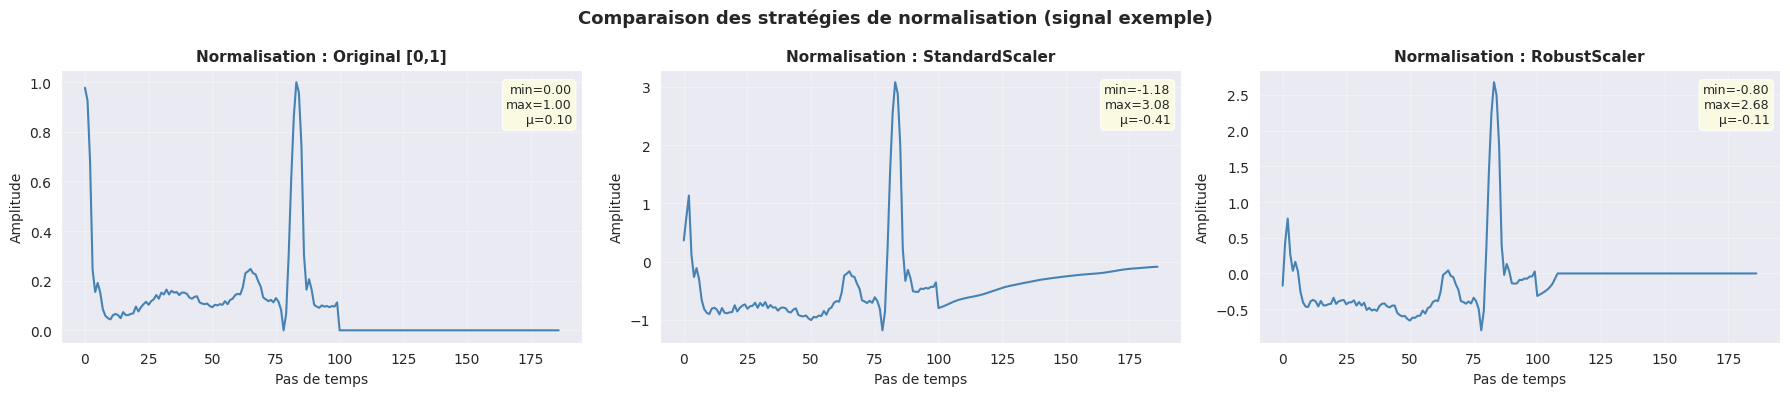

   ✅ Figure sauvegardée : normalization_comparison.png

   📌 Décision : données originales conservées (déjà dans [0,1])
      → Pas de risque de fuite de données, normalisation robuste.

✂️  3.4 — Split Train / Validation / Test...
   Train      : 70043 échantillons (80%)
   Validation : 17511 échantillons (20%)
   Test       : 21892 échantillons (fixé par Kaggle)

   Shape 2D (ML classique) : (70043, 187)
   Shape 3D (CNN/LSTM)     : (70043, 187, 1)

📊 3.5 — Vérification de la stratification :


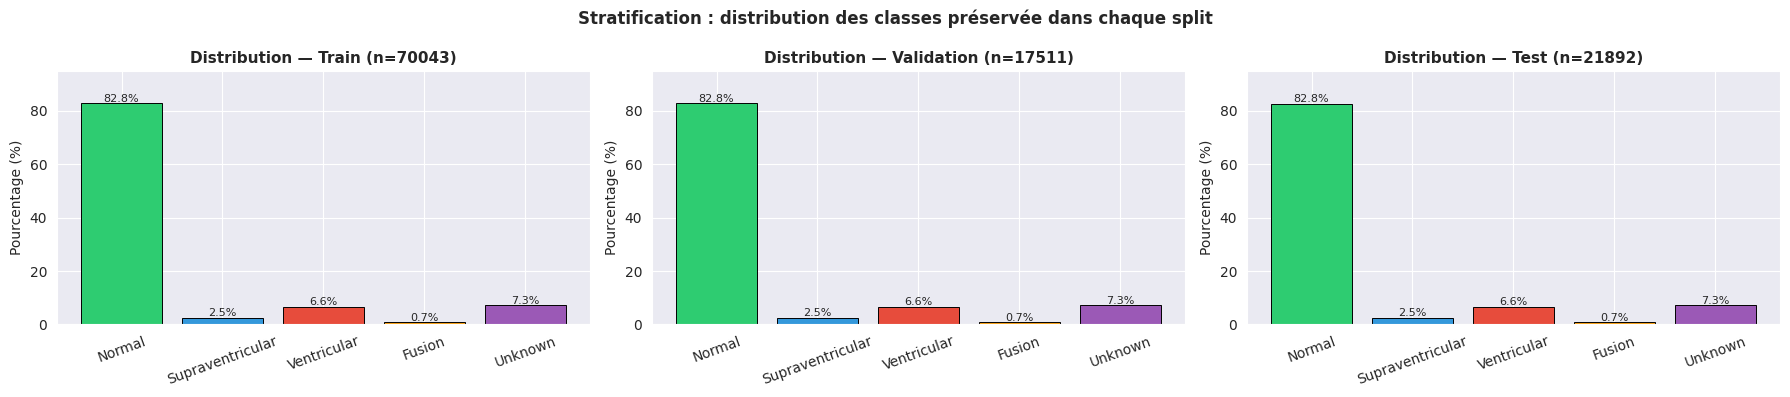

   ✅ Figure sauvegardée : stratification_check.png

✅ PRÉTRAITEMENT TERMINÉ
   X_tr      : (70043, 187)   y_tr      : (70043,)
   X_val     : (17511, 187)  y_val     : (17511,)
   X_test    : (21892, 187)  y_test    : (21892,)
   X_tr_3d   : (70043, 187, 1) (pour CNN/LSTM)


In [3]:
# ============================================================
# CELLULE 3 — Prétraitement des données
# ============================================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

print("=" * 60)
print("         PRÉTRAITEMENT DES DONNÉES")
print("=" * 60)

# ------------------------------------------------------------
# 3.1 Vérification & Nettoyage
# ------------------------------------------------------------
print("\n🔍 3.1 — Vérification des données...")
print(f"   Valeurs manquantes (train) : {np.isnan(X_train).sum()}")
print(f"   Valeurs infinies  (train)  : {np.isinf(X_train).sum()}")
print(f"   Valeurs < 0               : {(X_train < 0).sum()}")
print(f"   Valeurs > 1               : {(X_train > 1).sum()}")
print("   ✅ Données déjà propres et normalisées [0, 1]")

# ------------------------------------------------------------
# 3.2 Encodage des labels (One-Hot pour DL)
# ------------------------------------------------------------
print("\n🏷️  3.2 — Encodage des labels...")
NUM_CLASSES = 5

y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"   y_train entier  : {y_train.shape}   — ex: {y_train[:3]}")
print(f"   y_train one-hot : {y_train_cat.shape} — ex:\n{y_train_cat[:3]}")

# ------------------------------------------------------------
# 3.3 Comparaison des stratégies de normalisation
# ------------------------------------------------------------
print("\n📏 3.3 — Comparaison des stratégies de normalisation...")

# Les données sont déjà dans [0,1] → on compare 3 stratégies
scalers = {
    'Original [0,1]'    : None,
    'StandardScaler'    : StandardScaler(),
    'RobustScaler'      : RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sample_signal = X_train[0]

for ax, (name, scaler) in zip(axes, scalers.items()):
    if scaler is None:
        signal = sample_signal
    else:
        signal = scaler.fit_transform(X_train)[0]
    ax.plot(signal, color='steelblue', linewidth=1.5)
    ax.set_title(f"Normalisation : {name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Pas de temps")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.95, f"min={signal.min():.2f}\nmax={signal.max():.2f}\nμ={signal.mean():.2f}",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle("Comparaison des stratégies de normalisation (signal exemple)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("normalization_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ Figure sauvegardée : normalization_comparison.png")

# Décision : on garde les données originales [0,1] → déjà normalisées par le dataset
print("\n   📌 Décision : données originales conservées (déjà dans [0,1])")
print("      → Pas de risque de fuite de données, normalisation robuste.")

# ------------------------------------------------------------
# 3.4 Split Train / Validation / Test
# ------------------------------------------------------------
print("\n✂️  3.4 — Split Train / Validation / Test...")

# Split train → 80% train, 20% validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train          # Préserve la distribution des classes
)

y_tr_cat  = to_categorical(y_tr,  num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)

print(f"   Train      : {X_tr.shape[0]} échantillons ({X_tr.shape[0]/X_train.shape[0]*100:.0f}%)")
print(f"   Validation : {X_val.shape[0]} échantillons ({X_val.shape[0]/X_train.shape[0]*100:.0f}%)")
print(f"   Test       : {X_test.shape[0]} échantillons (fixé par Kaggle)")

# Reshape pour CNN et LSTM (besoin de 3D : [samples, timesteps, features])
X_tr_3d   = X_tr.reshape(-1, 187, 1)
X_val_3d  = X_val.reshape(-1, 187, 1)
X_test_3d = X_test.reshape(-1, 187, 1)

print(f"\n   Shape 2D (ML classique) : {X_tr.shape}")
print(f"   Shape 3D (CNN/LSTM)     : {X_tr_3d.shape}")

# ------------------------------------------------------------
# 3.5 Vérification de la stratification
# ------------------------------------------------------------
print("\n📊 3.5 — Vérification de la stratification :")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
splits = {'Train'     : y_tr,
          'Validation': y_val,
          'Test'      : y_test}
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6']

for ax, (split_name, y_split) in zip(axes, splits.items()):
    unique, counts = np.unique(y_split, return_counts=True)
    pcts = counts / counts.sum() * 100
    bars = ax.bar([class_names[i] for i in unique], pcts, color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(f"Distribution — {split_name} (n={len(y_split)})", fontsize=11, fontweight='bold')
    ax.set_ylabel("Pourcentage (%)")
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 95)
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=8)

plt.suptitle("Stratification : distribution des classes préservée dans chaque split",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("stratification_check.png", dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ Figure sauvegardée : stratification_check.png")

print("\n" + "=" * 60)
print("✅ PRÉTRAITEMENT TERMINÉ")
print(f"   X_tr      : {X_tr.shape}   y_tr      : {y_tr.shape}")
print(f"   X_val     : {X_val.shape}  y_val     : {y_val.shape}")
print(f"   X_test    : {X_test.shape}  y_test    : {y_test.shape}")
print(f"   X_tr_3d   : {X_tr_3d.shape} (pour CNN/LSTM)")
print("=" * 60)


   BASELINE — Random Forest

🔁 Cross-Validation 5-fold (sous-échantillon 20000)...
   F1-Macro CV folds : [0.8657 0.834  0.8299 0.8202 0.8338]
   Moyenne           : 0.8367 ± 0.0153

🌲 Entraînement sur tout le train...
   ✅ Entraînement terminé en 62.6s

📊 Résultats Random Forest (Test) :
   Accuracy : 0.9720
   F1-Macro : 0.8554

📋 Rapport de classification :
                  precision    recall  f1-score   support

          Normal       0.97      1.00      0.98     18118
Supraventricular       0.97      0.57      0.72       556
     Ventricular       0.98      0.87      0.92      1448
          Fusion       0.83      0.59      0.69       162
         Unknown       1.00      0.94      0.97      1608

        accuracy                           0.97     21892
       macro avg       0.95      0.79      0.86     21892
    weighted avg       0.97      0.97      0.97     21892



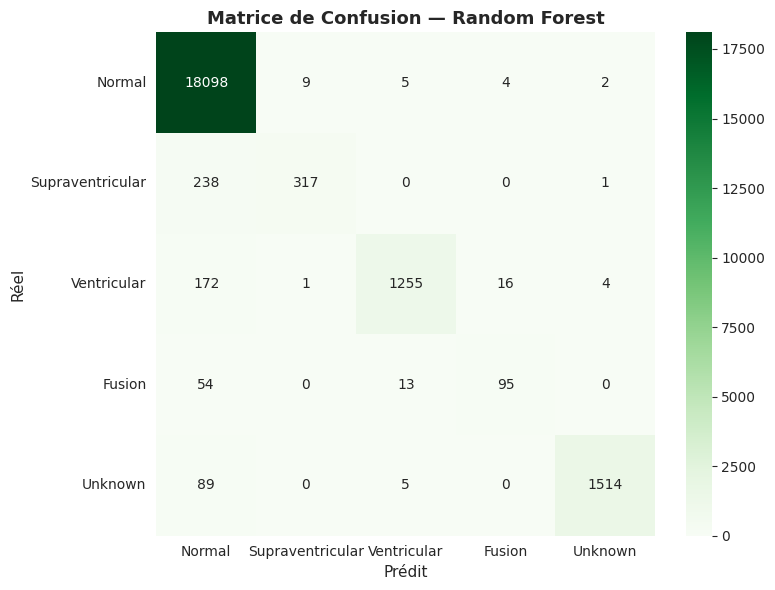


✅ Random Forest — Accuracy: 0.9720 | F1-Macro: 0.8554


In [4]:
# ============================================================
# CELLULE 4 — Baseline : Random Forest + Cross-Validation
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import time

print("=" * 60)
print("   BASELINE — Random Forest")
print("=" * 60)

# ------------------------------------------------------------
# 4.1 Cross-Validation (5 folds, sous-ensemble pour rapidité)
# ------------------------------------------------------------
print("\n🔁 Cross-Validation 5-fold (sous-échantillon 20000)...")
np.random.seed(42)
idx_cv = np.random.choice(len(X_tr), size=20000, replace=False)
X_cv, y_cv = X_tr[idx_cv], y_tr[idx_cv]

rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cv, X_cv, y_cv, cv=skf, scoring='f1_macro', n_jobs=-1)

print(f"   F1-Macro CV folds : {cv_scores.round(4)}")
print(f"   Moyenne           : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ------------------------------------------------------------
# 4.2 Entraînement sur tout le train
# ------------------------------------------------------------
print("\n🌲 Entraînement sur tout le train...")
start = time.time()
rf_model = RandomForestClassifier(n_estimators=200, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
rf_model.fit(X_tr, y_tr)
elapsed = time.time() - start
print(f"   ✅ Entraînement terminé en {elapsed:.1f}s")

# ------------------------------------------------------------
# 4.3 Évaluation
# ------------------------------------------------------------
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')

print(f"\n📊 Résultats Random Forest (Test) :")
print(f"   Accuracy : {acc_rf:.4f}")
print(f"   F1-Macro : {f1_rf:.4f}")
print("\n📋 Rapport de classification :")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Matrice de Confusion — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédit", fontsize=11)
ax.set_ylabel("Réel", fontsize=11)
plt.tight_layout()
plt.savefig("cm_random_forest.png", dpi=150, bbox_inches='tight')
plt.show()

# Stockage des résultats pour comparaison finale
results = {}
results['Random Forest'] = {'accuracy': acc_rf, 'f1_macro': f1_rf}
print(f"\n✅ Random Forest — Accuracy: {acc_rf:.4f} | F1-Macro: {f1_rf:.4f}")


   ANN — Multilayer Perceptron


I0000 00:00:1777480556.627110      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777480556.633171      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ANN_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        48,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,317 (364.52 KB)

...


🚀 Entraînement ANN...
Epoch 1/50


I0000 00:00:1777480560.759710     178 service.cc:152] XLA service 0x7c64ec013ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777480560.759759     178 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777480560.759766     178 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777480561.321819     178 cuda_dnn.cc:529] Loaded cuDNN version 91002


 56/274 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4907 - loss: 1.2728

I0000 00:00:1777480564.846695     178 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7521 - loss: 0.7082 - val_accuracy: 0.9146 - val_loss: 0.2775 - learning_rate: 0.0010
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9357 - loss: 0.2358 - val_accuracy: 0.9410 - val_loss: 0.1945 - learning_rate: 0.0010
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9475 - loss: 0.1955 - val_accuracy: 0.9583 - val_loss: 0.1414 - learning_rate: 0.0010
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9520 - loss: 0.1738 - val_accuracy: 0.9636 - val_loss: 0.1257 - learning_rate: 0.0010
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1596 - val_accuracy: 0.9648 - val_loss: 0.1214 - learning_rate: 0.0010
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9602 - loss: 0.1471 - val_accuracy: 0.9681 - val_loss: 0.1102 - learning_rate: 0.0010
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9614 - loss: 0.1395 - val_accur

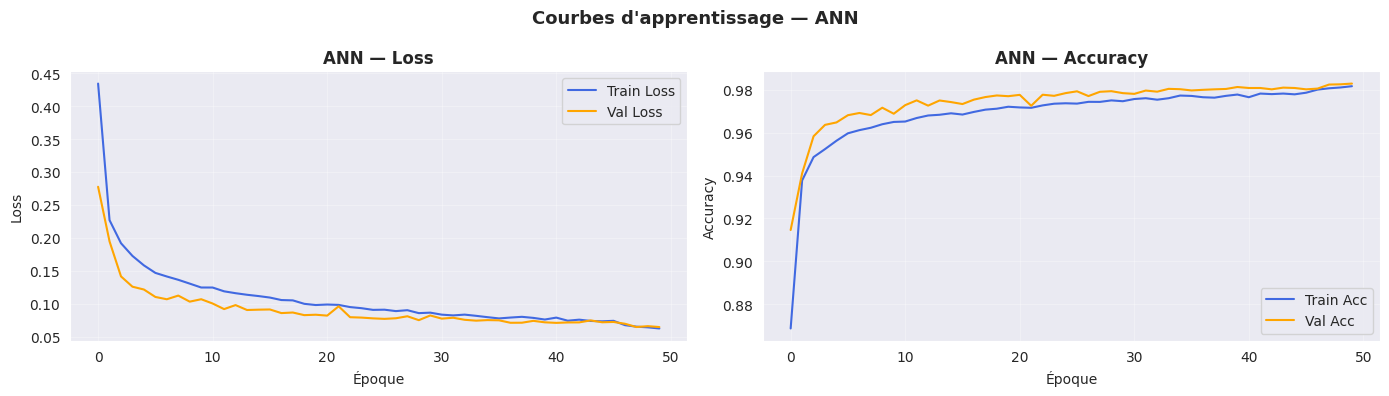

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

📊 Résultats ANN (Test) :
   Accuracy : 0.9811
   F1-Macro : 0.8964
                  precision    recall  f1-score   support

          Normal       0.99      1.00      0.99     18118
Supraventricular       0.90      0.71      0.79       556
     Ventricular       0.95      0.94      0.95      1448
          Fusion       0.81      0.73      0.77       162
         Unknown       0.99      0.98      0.99      1608

        accuracy                           0.98     21892
       macro avg       0.93      0.87      0.90     21892
    weighted avg       0.98      0.98      0.98     21892



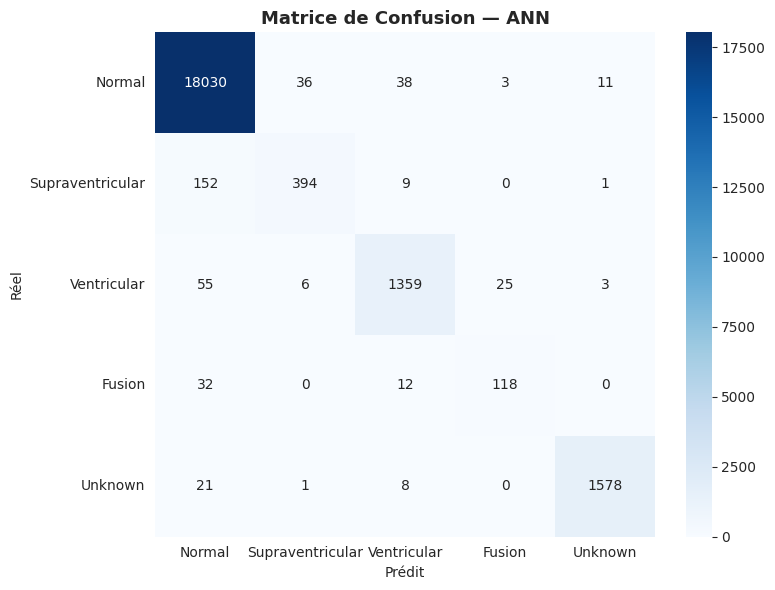


✅ ANN — Accuracy: 0.9811 | F1-Macro: 0.8964


In [5]:
# ============================================================
# CELLULE 5 — ANN : Artificial Neural Network (MLP)
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import time

print("=" * 60)
print("   ANN — Multilayer Perceptron")
print("=" * 60)

# ------------------------------------------------------------
# 5.1 Architecture
# ------------------------------------------------------------
tf.random.set_seed(42)

ann_model = Sequential([
    Dense(256, activation='relu', input_shape=(187,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(5, activation='softmax')
], name="ANN_MLP")

ann_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

# ------------------------------------------------------------
# 5.2 Callbacks
# ------------------------------------------------------------
callbacks_ann = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

# ------------------------------------------------------------
# 5.3 Entraînement
# ------------------------------------------------------------
print("\n🚀 Entraînement ANN...")
start = time.time()
history_ann = ann_model.fit(
    X_tr, y_tr_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=256,
    callbacks=callbacks_ann,
    verbose=1
)
elapsed = time.time() - start
print(f"\n   ✅ Entraînement terminé en {elapsed:.1f}s")

# ------------------------------------------------------------
# 5.4 Courbes d'apprentissage
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_ann.history['loss'],     label='Train Loss', color='royalblue')
axes[0].plot(history_ann.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title("ANN — Loss", fontweight='bold')
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ann.history['accuracy'],     label='Train Acc', color='royalblue')
axes[1].plot(history_ann.history['val_accuracy'], label='Val Acc',   color='orange')
axes[1].set_title("ANN — Accuracy", fontweight='bold')
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — ANN", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("curves_ann.png", dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 5.5 Évaluation
# ------------------------------------------------------------
y_pred_ann = np.argmax(ann_model.predict(X_test), axis=1)
acc_ann = accuracy_score(y_test, y_pred_ann)
f1_ann  = f1_score(y_test, y_pred_ann, average='macro')

print(f"\n📊 Résultats ANN (Test) :")
print(f"   Accuracy : {acc_ann:.4f}")
print(f"   F1-Macro : {f1_ann:.4f}")
print(classification_report(y_test, y_pred_ann, target_names=class_names))

cm_ann = confusion_matrix(y_test, y_pred_ann)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Matrice de Confusion — ANN", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig("cm_ann.png", dpi=150, bbox_inches='tight')
plt.show()

# On s'assure que le dictionnaire existe dans cette session GPU
if 'results' not in locals():
    results = {}

results['ANN'] = {'accuracy': acc_ann, 'f1_macro': f1_ann}
print(f"\n✅ ANN — Accuracy: {acc_ann:.4f} | F1-Macro: {f1_ann:.4f}")

   CNN — Conv1D pour séries temporelles


Model: "CNN_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 46, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,877 (687.02 KB)

 Trainable params: 174,725 (682.52 KB)

 Non-trainable params: 1,152 (4.50 KB)


🚀 Entraînement CNN...
Epoch 1/50


2026-04-29 16:37:08.657926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 16:37:08.935368: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.6765 - loss: 1.0609 - val_accuracy: 0.0256 - val_loss: 1.6517 - learning_rate: 0.0010
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9477 - loss: 0.1959 - val_accuracy: 0.0778 - val_loss: 4.6399 - learning_rate: 0.0010
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9552 - loss: 0.1619 - val_accuracy: 0.4615 - val_loss: 1.8579 - learning_rate: 0.0010
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9629 - loss: 0.1388 - val_accuracy: 0.9611 - val_loss: 0.1295 - learning_rate: 0.0010
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9648 - loss: 0.1276 - val_accuracy: 0.9643 - val_loss: 0.1361 - learning_rate: 0.0010
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9688 - loss: 0.1141 - val_accuracy: 0.9619 - val_loss: 0.1599 - learning_rate: 0.0010
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9701 - loss: 0.1099 - val

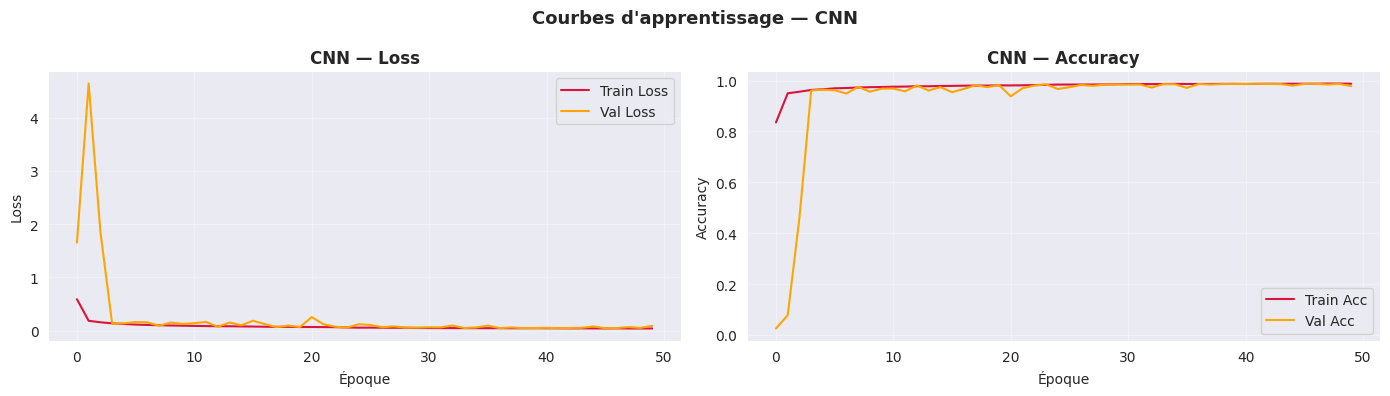

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

📊 Résultats CNN (Test) :
   Accuracy : 0.9867
   F1-Macro : 0.9192
                  precision    recall  f1-score   support

          Normal       0.99      1.00      0.99     18118
Supraventricular       0.95      0.73      0.83       556
     Ventricular       0.96      0.97      0.97      1448
          Fusion       0.92      0.73      0.82       162
         Unknown       1.00      0.99      0.99      1608

        accuracy                           0.99     21892
       macro avg       0.96      0.89      0.92     21892
    weighted avg       0.99      0.99      0.99     21892



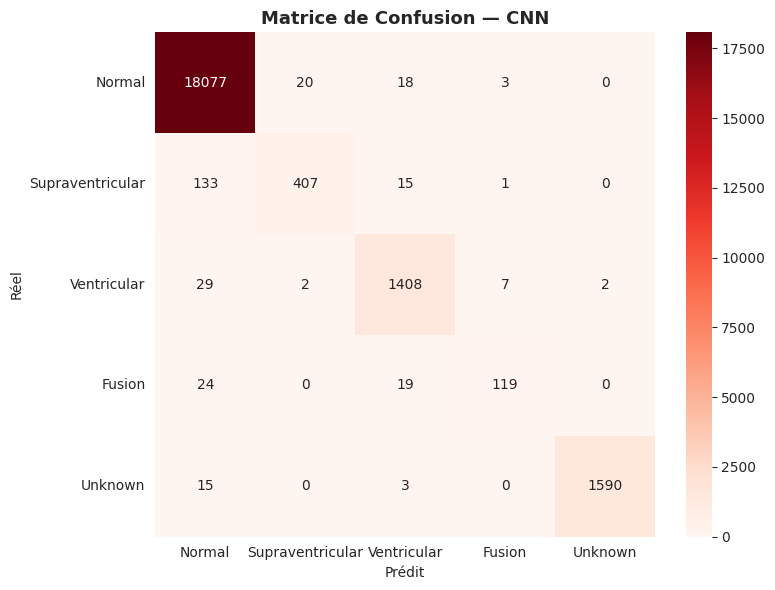


✅ CNN — Accuracy: 0.9867 | F1-Macro: 0.9192


In [6]:
# ============================================================
# CELLULE 6 — CNN : Convolutional Neural Network (Conv1D)
# ============================================================

from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
import time

print("=" * 60)
print("   CNN — Conv1D pour séries temporelles")
print("=" * 60)

# ------------------------------------------------------------
# 6.1 Architecture
# ------------------------------------------------------------
tf.random.set_seed(42)

cnn_model = Sequential([
    Conv1D(64, kernel_size=5, activation='relu', input_shape=(187, 1), padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(5, activation='softmax')
], name="CNN_Conv1D")

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# ------------------------------------------------------------
# 6.2 Entraînement
# ------------------------------------------------------------
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

print("\n🚀 Entraînement CNN...")
start = time.time()
history_cnn = cnn_model.fit(
    X_tr_3d, y_tr_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=50,
    batch_size=256,
    callbacks=callbacks_cnn,
    verbose=1
)
elapsed = time.time() - start
print(f"\n   ✅ Entraînement terminé en {elapsed:.1f}s")

# ------------------------------------------------------------
# 6.3 Courbes d'apprentissage
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_cnn.history['loss'],     label='Train Loss', color='crimson')
axes[0].plot(history_cnn.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title("CNN — Loss", fontweight='bold')
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['accuracy'],     label='Train Acc', color='crimson')
axes[1].plot(history_cnn.history['val_accuracy'], label='Val Acc',   color='orange')
axes[1].set_title("CNN — Accuracy", fontweight='bold')
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — CNN", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("curves_cnn.png", dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 6.4 Évaluation
# ------------------------------------------------------------
y_pred_cnn = np.argmax(cnn_model.predict(X_test_3d), axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn  = f1_score(y_test, y_pred_cnn, average='macro')

print(f"\n📊 Résultats CNN (Test) :")
print(f"   Accuracy : {acc_cnn:.4f}")
print(f"   F1-Macro : {f1_cnn:.4f}")
print(classification_report(y_test, y_pred_cnn, target_names=class_names))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Matrice de Confusion — CNN", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig("cm_cnn.png", dpi=150, bbox_inches='tight')
plt.show()

results['CNN'] = {'accuracy': acc_cnn, 'f1_macro': f1_cnn}
print(f"\n✅ CNN — Accuracy: {acc_cnn:.4f} | F1-Macro: {f1_cnn:.4f}")


   RNN — LSTM Bidirectionnel


Model: "BiLSTM_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 187, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,517 (314.52 KB)

 Trainable params: 80,005 (312.52 KB)

 Non-trainable params: 512 (2.00 KB)


🚀 Entraînement LSTM...
Epoch 1/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.6634 - loss: 1.0897 - val_accuracy: 0.8220 - val_loss: 0.8252 - learning_rate: 0.0010
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.9298 - loss: 0.2956 - val_accuracy: 0.9228 - val_loss: 0.3398 - learning_rate: 0.0010
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.9398 - loss: 0.2391 - val_accuracy: 0.9398 - val_loss: 0.2300 - learning_rate: 0.0010
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.9457 - loss: 0.2137 - val_accuracy: 0.9507 - val_loss: 0.1867 - learning_rate: 0.0010
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.9512 - loss: 0.1901 - val_accuracy: 0.9494 - val_loss: 0.1976 - learning_rate: 0.0010
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.9542 - loss: 0.1787 - val_accuracy: 0.9525 - val_loss: 0.1717 - learning_rate: 0.0010
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/ste

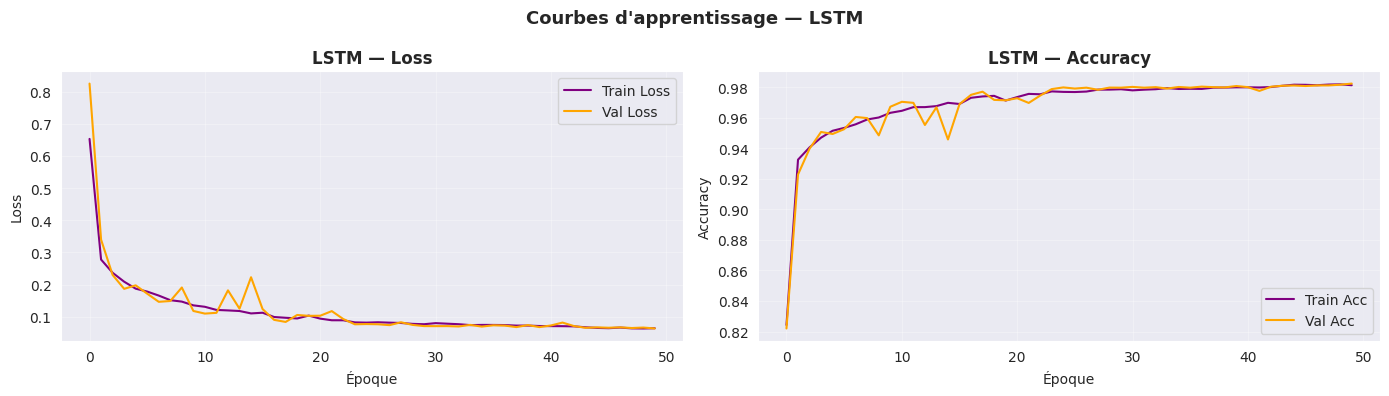

685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step

📊 Résultats LSTM (Test) :
   Accuracy : 0.9803
   F1-Macro : 0.8944
                  precision    recall  f1-score   support

          Normal       0.98      1.00      0.99     18118
Supraventricular       0.90      0.69      0.78       556
     Ventricular       0.97      0.92      0.95      1448
          Fusion       0.81      0.74      0.77       162
         Unknown       0.99      0.98      0.98      1608

        accuracy                           0.98     21892
       macro avg       0.93      0.86      0.89     21892
    weighted avg       0.98      0.98      0.98     21892



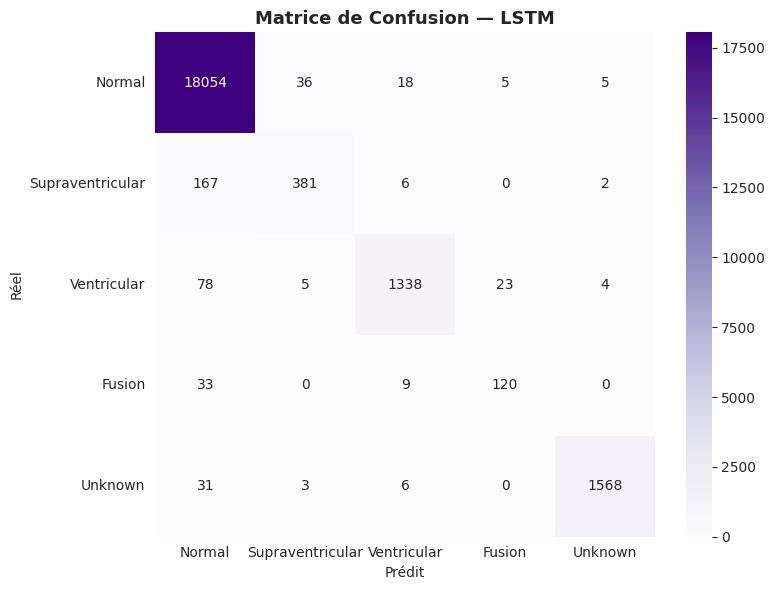


✅ LSTM — Accuracy: 0.9803 | F1-Macro: 0.8944


In [7]:
# ============================================================
# CELLULE 7 — RNN : LSTM pour séries temporelles ECG
# ============================================================

from tensorflow.keras.layers import LSTM, Bidirectional
import time

print("=" * 60)
print("   RNN — LSTM Bidirectionnel")
print("=" * 60)

# ------------------------------------------------------------
# 7.1 Architecture
# ------------------------------------------------------------
tf.random.set_seed(42)

lstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(187, 1)),
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(32, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(5, activation='softmax')
], name="BiLSTM_RNN")

lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

# ------------------------------------------------------------
# 7.2 Entraînement
# ------------------------------------------------------------
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1)
]

print("\n🚀 Entraînement LSTM...")
start = time.time()
history_lstm = lstm_model.fit(
    X_tr_3d, y_tr_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=50,
    batch_size=256,
    callbacks=callbacks_lstm,
    verbose=1
)
elapsed = time.time() - start
print(f"\n   ✅ Entraînement terminé en {elapsed:.1f}s")

# ------------------------------------------------------------
# 7.3 Courbes d'apprentissage
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_lstm.history['loss'],     label='Train Loss', color='purple')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title("LSTM — Loss", fontweight='bold')
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['accuracy'],     label='Train Acc', color='purple')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Acc',   color='orange')
axes[1].set_title("LSTM — Accuracy", fontweight='bold')
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — LSTM", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("curves_lstm.png", dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 7.4 Évaluation
# ------------------------------------------------------------
y_pred_lstm = np.argmax(lstm_model.predict(X_test_3d), axis=1)
acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm, average='macro')

print(f"\n📊 Résultats LSTM (Test) :")
print(f"   Accuracy : {acc_lstm:.4f}")
print(f"   F1-Macro : {f1_lstm:.4f}")
print(classification_report(y_test, y_pred_lstm, target_names=class_names))

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Matrice de Confusion — LSTM", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig("cm_lstm.png", dpi=150, bbox_inches='tight')
plt.show()

results['LSTM'] = {'accuracy': acc_lstm, 'f1_macro': f1_lstm}
print(f"\n✅ LSTM — Accuracy: {acc_lstm:.4f} | F1-Macro: {f1_lstm:.4f}")


ÉVALUATION COMPARATIVE FINALE

📊 Tableau comparatif :
Modèle               Accuracy   F1-Macro
------------------------------------------
Random Forest          0.9720     0.8554
ANN                    0.9811     0.8964
LSTM                   0.9803     0.8944
CNN                    0.9867     0.9192 ⭐


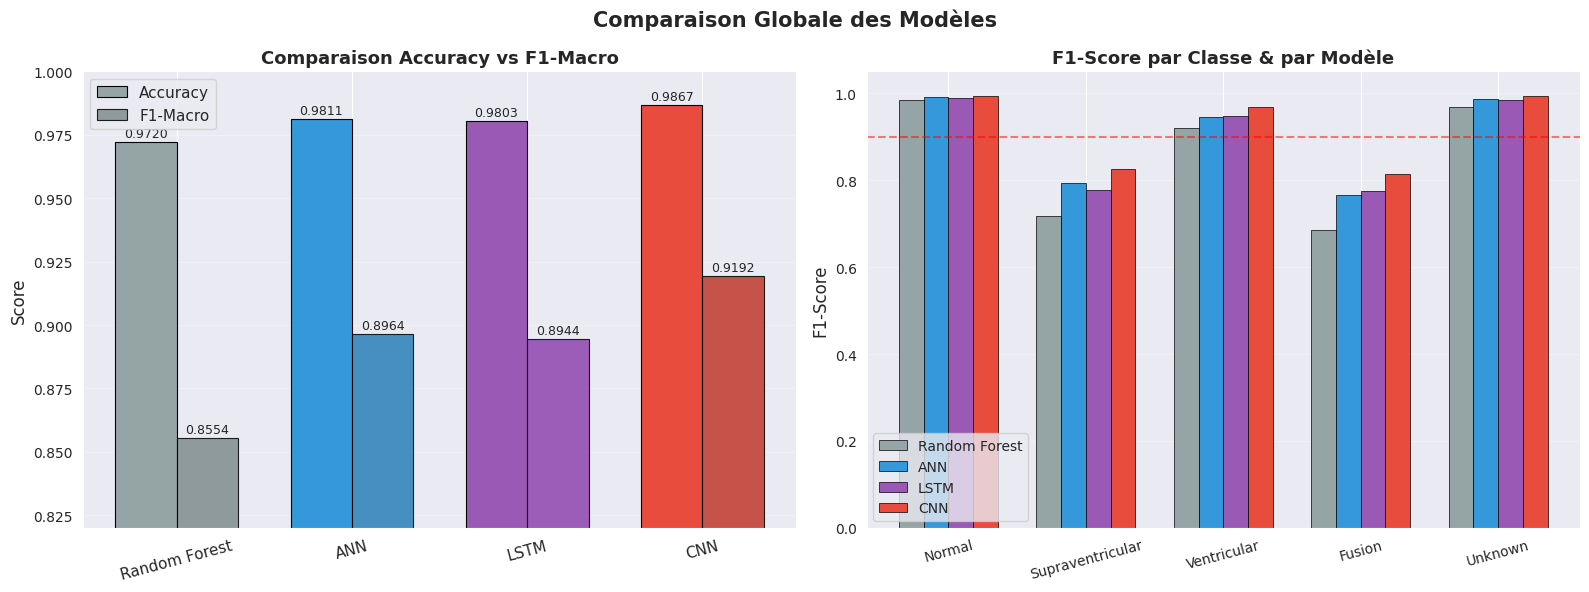

✅ Figure sauvegardée : model_comparison.png


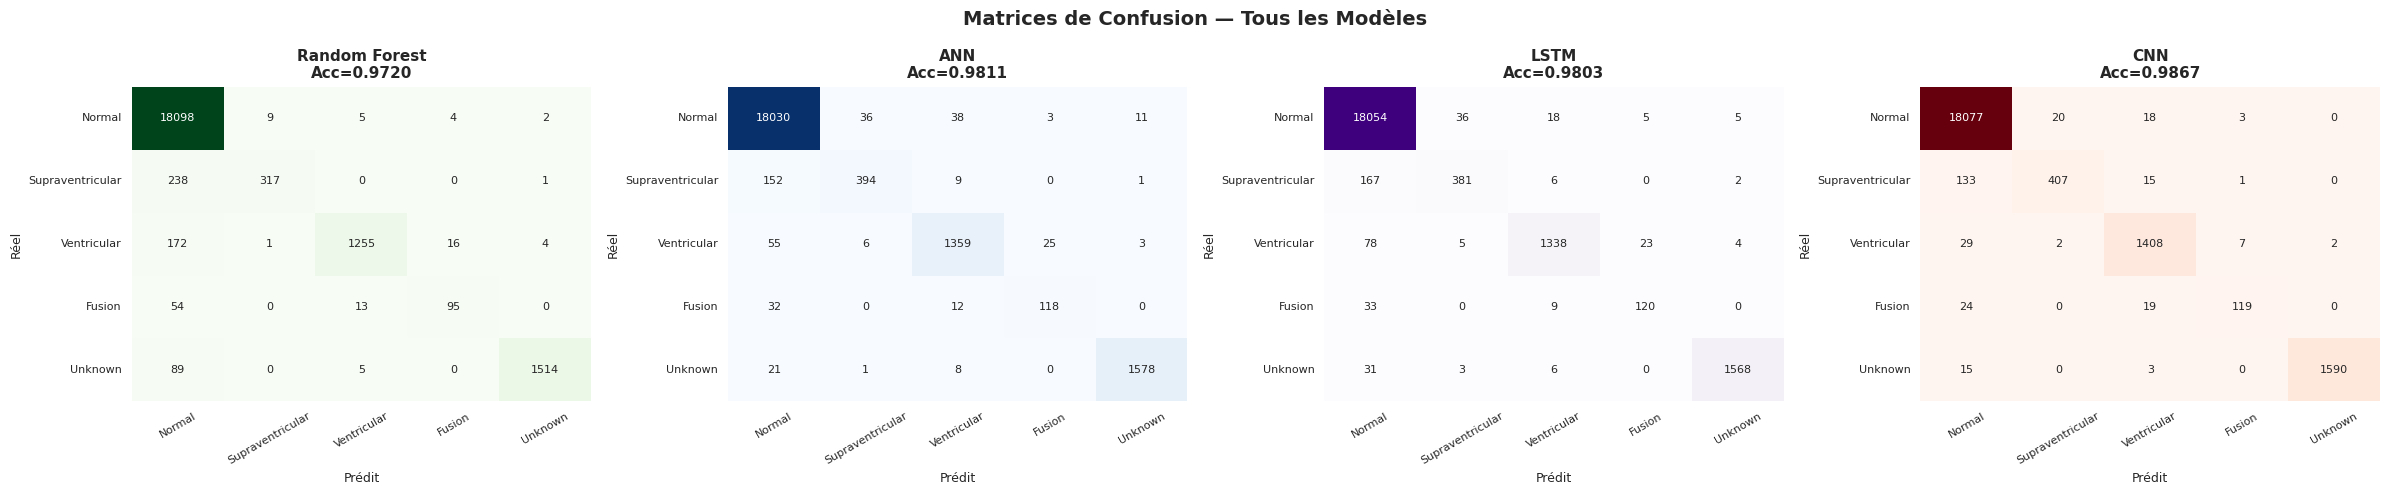

✅ Figure sauvegardée : all_confusion_matrices.png


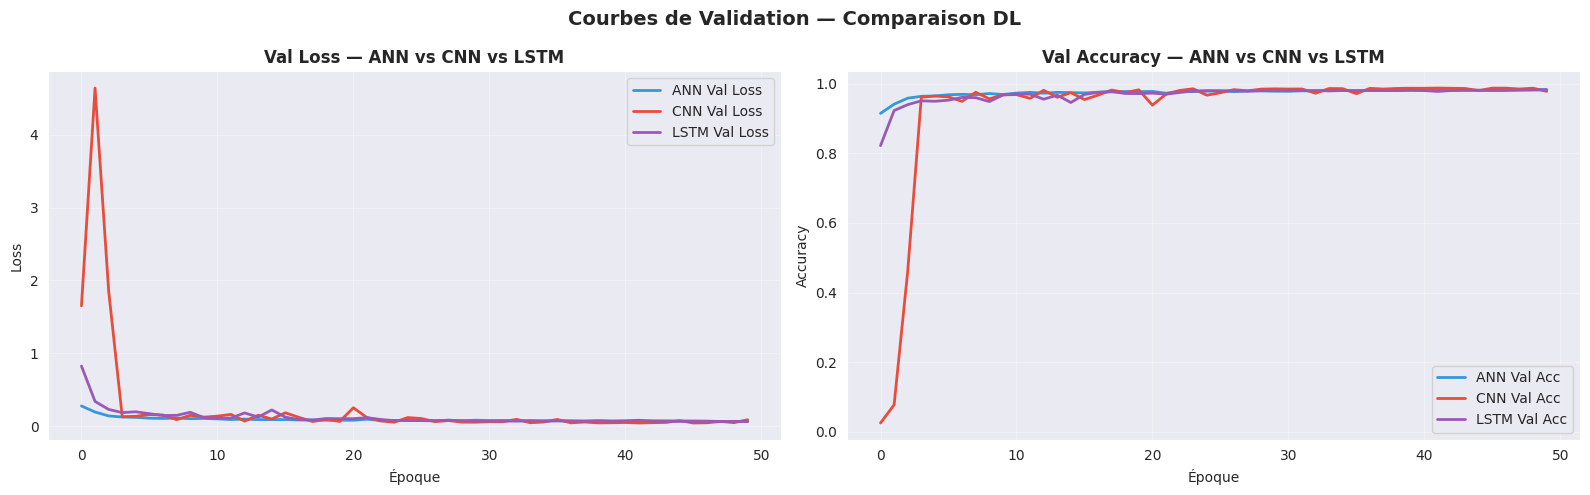

✅ Figure sauvegardée : val_curves_comparison.png

  RÉSUMÉ FINAL
  Random Forest      Acc=0.9720  F1=0.8554
  ANN                Acc=0.9811  F1=0.8964
  LSTM               Acc=0.9803  F1=0.8944
  CNN                Acc=0.9867  F1=0.9192
--------------------------------------------------
  🏆 Meilleur modèle : CNN
     Accuracy : 0.9867
     F1-Macro : 0.9192


In [8]:
# CELLULE 8 — Comparaison & Visualisation Finale

import matplotlib.gridspec as gridspec

print("ÉVALUATION COMPARATIVE FINALE")
print("=" * 50)

# -------------------------------------------------------
# 8.1 Récapitulatif des métriques (déjà calculées)
# -------------------------------------------------------

model_names  = ['Random Forest', 'ANN', 'LSTM', 'CNN']
accuracies   = [results['Random Forest']['accuracy'],
                results['ANN']['accuracy'],
                results['LSTM']['accuracy'],
                results['CNN']['accuracy']]
f1_macros    = [results['Random Forest']['f1_macro'],
                results['ANN']['f1_macro'],
                results['LSTM']['f1_macro'],
                results['CNN']['f1_macro']]

print("\n📊 Tableau comparatif :")
print(f"{'Modèle':<18} {'Accuracy':>10} {'F1-Macro':>10}")
print("-" * 42)
for name, acc, f1 in zip(model_names, accuracies, f1_macros):
    star = " ⭐" if f1 == max(f1_macros) else ""
    print(f"{name:<18} {acc:>10.4f} {f1:>10.4f}{star}")

# -------------------------------------------------------
# 8.2 Barplot comparatif Accuracy vs F1-Macro
# -------------------------------------------------------

x = np.arange(len(model_names))
width = 0.35
colors_acc = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c']
colors_f1  = ['#7f8c8d', '#2980b9', '#8e44ad', '#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars1 = axes[0].bar(x - width/2, accuracies, width,
                    label='Accuracy', color=colors_acc, edgecolor='black', linewidth=0.8)
bars2 = axes[0].bar(x + width/2, f1_macros,  width,
                    label='F1-Macro', color=colors_f1, edgecolor='black', linewidth=0.8, alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, fontsize=11)
axes[0].set_ylim(0.82, 1.00)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Comparaison Accuracy vs F1-Macro", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# -------------------------------------------------------
# 8.3 F1-score par classe pour chaque modèle
# -------------------------------------------------------

from sklearn.metrics import f1_score

y_preds = {
    'Random Forest': y_pred_rf,
    'ANN'          : y_pred_ann,
    'LSTM'         : y_pred_lstm,
    'CNN'          : y_pred_cnn,
}

f1_per_class = {}
for name, y_pred in y_preds.items():
    f1_per_class[name] = f1_score(y_test, y_pred, average=None)

x2    = np.arange(len(class_names))
width2 = 0.18
colors_model = ['#95a5a6', '#3498db', '#9b59b6', '#e74c3c']

for i, (name, f1s) in enumerate(f1_per_class.items()):
    axes[1].bar(x2 + i * width2, f1s, width2,
                label=name, color=colors_model[i],
                edgecolor='black', linewidth=0.5)

axes[1].set_xticks(x2 + width2 * 1.5)
axes[1].set_xticklabels(class_names, rotation=15, fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("F1-Score", fontsize=12)
axes[1].set_title("F1-Score par Classe & par Modèle", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Seuil 0.90')

plt.suptitle("Comparaison Globale des Modèles", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : model_comparison.png")

# -------------------------------------------------------
# 8.4 4 Matrices de confusion côte à côte
# -------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
cms   = [confusion_matrix(y_test, y_pred_rf),
         confusion_matrix(y_test, y_pred_ann),
         confusion_matrix(y_test, y_pred_lstm),
         confusion_matrix(y_test, y_pred_cnn)]
cmaps = ['Greens', 'Blues', 'Purples', 'Reds']

for ax, cm, name, cmap in zip(axes, cms, model_names, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False, annot_kws={"size": 8})
    acc = accuracy_score(y_test,
          [y_pred_rf, y_pred_ann, y_pred_lstm, y_pred_cnn][model_names.index(name)])
    ax.set_title(f"{name}\nAcc={acc:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel",   fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle("Matrices de Confusion — Tous les Modèles",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : all_confusion_matrices.png")

# -------------------------------------------------------
# 8.5 Courbes d'apprentissage DL superposées
# -------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
dl_histories = {
    'ANN'  : (history_ann,  '#3498db'),
    'CNN'  : (history_cnn,  '#e74c3c'),
    'LSTM' : (history_lstm, '#9b59b6'),
}

for name, (hist, color) in dl_histories.items():
    axes[0].plot(hist.history['val_loss'],
                 label=f'{name} Val Loss', color=color, linewidth=2)
    axes[1].plot(hist.history['val_accuracy'],
                 label=f'{name} Val Acc', color=color, linewidth=2)

axes[0].set_title("Val Loss — ANN vs CNN vs LSTM", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Val Accuracy — ANN vs CNN vs LSTM", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes de Validation — Comparaison DL", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("val_curves_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : val_curves_comparison.png")

# -------------------------------------------------------
# 8.6 Résumé final
# -------------------------------------------------------
best_idx = np.argmax(f1_macros)
print("\n" + "=" * 50)
print("  RÉSUMÉ FINAL")
print("=" * 50)
for name, acc, f1 in zip(model_names, accuracies, f1_macros):
    print(f"  {name:<18} Acc={acc:.4f}  F1={f1:.4f}")
print("-" * 50)
print(f"  🏆 Meilleur modèle : {model_names[best_idx]}")
print(f"     Accuracy : {accuracies[best_idx]:.4f}")
print(f"     F1-Macro : {f1_macros[best_idx]:.4f}")
print("=" * 50)
